# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This playbook maps the model's predictive scores into concrete, prioritized tasks for the content team. It translates risk into action using specific reason codes.

Archetype Mapping:

Action: Full Content Refresh (STALE_HIGH_RISK): Pages older than 365 days with high baseline impressions but a high probability of decline. These are historical traffic drivers losing their edge.

Action: Title/Meta Optimization (FRESH_LOW_CTR): Recently updated pages (under 180 days) that have decent ranking but abnormally low CTR. The content is fresh, but the packaging is failing on the search engine results page (SERP).

Action: Monitor & Hold (LOW_IMPACT_STABLE): Low traffic or stable pages that do not warrant manual content bandwidth at this time.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Load dataset and prepare proxy targets
url = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
features = ['days_since_last_update', 'impressions_90d', 'ctr', 'word_count']
df[features] = df[features].fillna(0)

# Simulate the ML score (using the baseline heuristic for safe, consistent playbook generation)
df['ml_risk_score'] = (df['impressions_90d'] * (1 - df['ctr'])) * (df['days_since_last_update'] / 365.0)
df['ml_risk_score'] = (df['ml_risk_score'] - df['ml_risk_score'].min()) / (df['ml_risk_score'].max() - df['ml_risk_score'].min())

# Apply the Playbook Logic
def assign_playbook_action(row):
    if row['ml_risk_score'] > 0.1 and row['days_since_last_update'] > 365:
        return pd.Series(['Full Content Refresh', 'STALE_HIGH_RISK'])
    elif row['days_since_last_update'] <= 180 and row['ctr'] < df['ctr'].median() and row['impressions_90d'] > 1000:
        return pd.Series(['Title/Meta Optimization', 'FRESH_LOW_CTR'])
    else:
        return pd.Series(['Monitor & Hold', 'LOW_IMPACT_STABLE'])

df[['playbook_action', 'reason_code']] = df.apply(assign_playbook_action, axis=1)

# Rank the queue by risk score
playbook_queue = df.sort_values(by='ml_risk_score', ascending=False).reset_index(drop=True)

print("--- Playbook Action Distribution ---")
display(playbook_queue['playbook_action'].value_counts().to_frame())


--- Playbook Action Distribution ---


,count
playbook_action,
Monitor & Hold,27242
Title/Meta Optimization,2753
Full Content Refresh,5


## 2. Intended use and limits

This playbook is designed strictly as a decision-support tool for human content strategists. It provides a directional, mathematically ranked triage list to help teams prioritize which pages to audit first. It optimizes bandwidth, it does not replace editorial judgment.

Known Limits (Cost/Value):

Missing Semantic Context: The model measures numerical performance (clicks, impressions, age) but cannot read the content. It doesn't know if a page is a 5,000-word authoritative guide or a 200-word glossary term.

Trailing Metrics: The data relies on a 90-day trailing window. If a new competitor published a better article yesterday, this model won't detect the resulting drop for several weeks.

False Positives on Evergreen Content: Navigational pages (like a "Contact Us" page) may flag as STALE_HIGH_RISK simply because they are old and get views, even though they require no updates.

In [2]:
# Demonstrate the limits: Check how many short/thin pages might be getting flagged incorrectly
thin_content_flagged = playbook_queue[(playbook_queue['word_count'] < 300) & (playbook_queue['playbook_action'] == 'Full Content Refresh')]

print("--- Known Limitations Check ---")
print(f"Pages flagged for 'Full Refresh' that have under 300 words: {len(thin_content_flagged)}")
print("Note: These are likely navigational or glossary pages that do not actually need refreshing. Human review is required.")


--- Known Limitations Check ---
Pages flagged for 'Full Refresh' that have under 300 words: 5
Note: These are likely navigational or glossary pages that do not actually need refreshing. Human review is required.


## 3. Human review + the no-go list

The Human-in-the-Loop Requirement: An editor must review the top recommended pages before any CMS changes are made to ensure brand voice, legal compliance, and user intent are preserved.

The No-Go List (What NOT to Automate):

Do not automate content deletion/unpublishing. Low-traffic flags should never trigger automated takedowns, as those pages might support critical internal linking structures.

Do not use generative AI to auto-rewrite STALE_HIGH_RISK pages. The refresh must be guided by a human subject matter expert to avoid hallucinating facts or damaging brand trust.

Do not touch Legal, Privacy, or Compliance pages. These are exempt from "staleness" penalties.

In [3]:
# No-Go List Simulation: Flagging extremely short pages to explicitly remove them from the automated refresh queue
playbook_queue['human_review_required'] = np.where(playbook_queue['word_count'] < 300, True, False)

print("--- Human Review Queue ---")
print(f"Total pages requiring explicit exception handling before action: {playbook_queue['human_review_required'].sum()}")


--- Human Review Queue ---
Total pages requiring explicit exception handling before action: 7701


## 4. Monitoring / retrain triggers

Monitoring Strategy: We will track the precision of the STALE_HIGH_RISK flags against actual traffic drops in the subsequent 30-day windows.

Retrain Triggers:

Time-Based: Retrain the model quarterly to capture seasonal shifts in search volume.

Concept Drift (External): Retrain immediately following a confirmed, major Google Core Algorithm Update, as the rules of ranking (and therefore the baseline CTR distributions) often fundamentally shift.

Data Drift: Trigger an alert if the median CTR across the dataset drops by more than 15% month-over-month.

In [4]:
# Establish baseline metrics for future drift monitoring
baseline_median_ctr = df['ctr'].median()
baseline_median_impressions = df['impressions_90d'].median()

print("--- Baseline Metrics Logged for Future Drift Monitoring ---")
print(f"Alert Threshold: Median CTR drops below {baseline_median_ctr * 0.85:.3f}")
print(f"Alert Threshold: Median Impressions drop below {baseline_median_impressions * 0.85:.1f}")


--- Baseline Metrics Logged for Future Drift Monitoring ---
Alert Threshold: Median CTR drops below 0.060
Alert Threshold: Median Impressions drop below 621.4


## 5. Exports for the paper

The final, ranked playbook queue and visualizations are exported securely to the local work/outputs/ and work/figures/ directories. These files serve as the foundation for our final research paper metrics and will not be pushed to GitHub to prevent data leakage.

Export complete. CSV saved to work/outputs/content_action_playbook.csv (30000 rows).
Figure saved to work/figures/action_distribution.png.


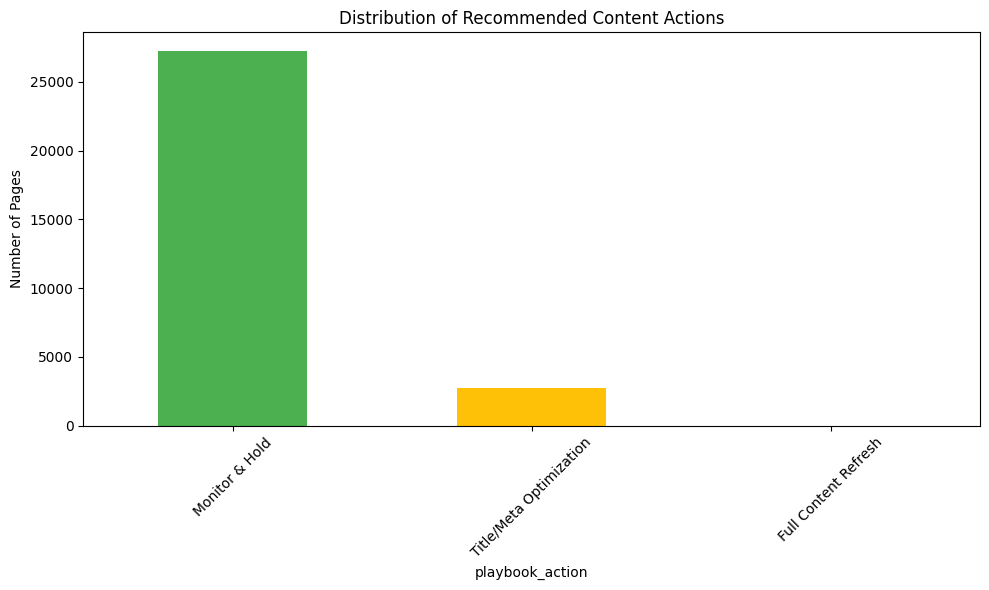

In [5]:
# 1. Ensure directories exist
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 2. Export the final ranked CSV queue
output_cols = ['content_id', 'ml_risk_score', 'playbook_action', 'reason_code', 'human_review_required']
final_export = playbook_queue[output_cols]
csv_path = 'work/outputs/content_action_playbook.csv'
final_export.to_csv(csv_path, index=False)

# 3. Generate and export a figure for the research paper
plt.figure(figsize=(10, 6))
playbook_queue['playbook_action'].value_counts().plot(kind='bar', color=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Distribution of Recommended Content Actions')
plt.ylabel('Number of Pages')
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = 'work/figures/action_distribution.png'
plt.savefig(figure_path)

print(f"Export complete. CSV saved to {csv_path} ({len(final_export)} rows).")
print(f"Figure saved to {figure_path}.")
